In [1]:
# Import python libraries
#import json
import os
import pathlib
from glob import glob

import earthpy.api.appeears as eaapp
import earthpy
import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import pandas as pd
import rioxarray as rxr
import xarray as xr
import holoviews as hv
import matplotlib.pyplot as plt
import osmnx as osm

In [2]:
# Search OSM for Menominee forest using geocode_to_gdf
osm_way_id = 16422130

# Retrieve polygon boundary
menominee_forest_boundary = osm.geocode_to_gdf(
    "R16422130",
    by_osmid=True
)

menominee_forest_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-89.36269 45.33622, -89.36259 ...",-89.641097,45.113805,-88.305856,45.766708,371560417,relation,16422130,45.418853,-88.614229,boundary,administrative,25,0.421191,administrative,Chequamegon-Nicolet National Forest - Lakewood...,Chequamegon-Nicolet National Forest - Lakewood...


<Axes: >

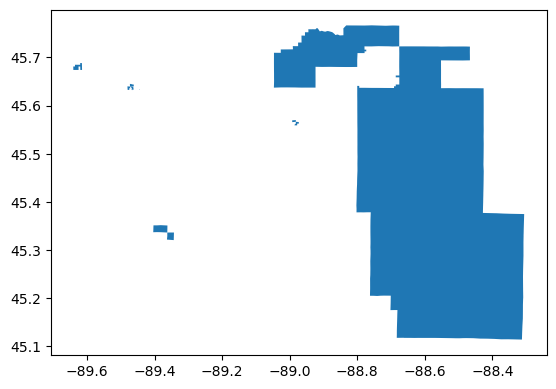

In [3]:
# Plot forest boundary
menominee_forest_boundary.plot()

In [4]:
# Create a project for file management
project = earthpy.Project(
    "Menominee Forest",
    dirname="menominee-vegetation"
)

In [5]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='menominee',
    project=project,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="06-01",
    end_date="09-01",
    recurring=True,
    year_range=[2002, 2025],
    polygon=menominee_forest_boundary
)

In [6]:
# Download the prepared download -- this can take some time!
ndvi_downloader.download_files(cache=False)

No stored credentials found for urs.earthdata.nasa.gov. Please log in.


/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:192: UserWarning: Setting credentials not supported for 'netrc' backend.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:196: UserWarning: Failed to store credentials with 'keyring': No recommended backend was available. Install a recommended 3rd party backend package; or, install the keyrings.alt package if you want to use the non-recommended backends. See https://pypi.org/project/keyring for details.
  warnings.warn(


Credentials stored using 'env' backend.


In [6]:
# Look at Wisconsin boundary

osm_way_id = 165466

# Retrieve polygon boundary
wisco_boundary = osm.geocode_to_gdf(
    "R165466",
    by_osmid=True
)

wisco_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-92.88931 45.64122, -92.88927 45.640...",-92.889315,42.491951,-86.249548,47.3025,371535280,relation,165466,44.430898,-89.688464,boundary,administrative,8,0.767679,state,Wisconsin,"Wisconsin, United States"


<Axes: >

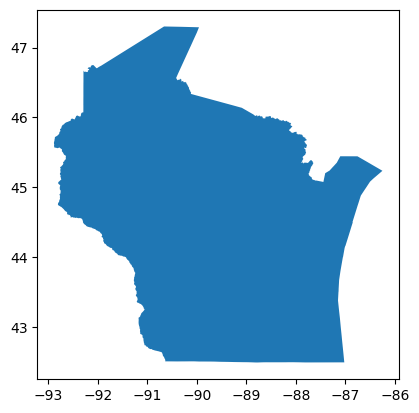

In [7]:
# Plot Wisconsin Boundary
wisco_boundary.plot()

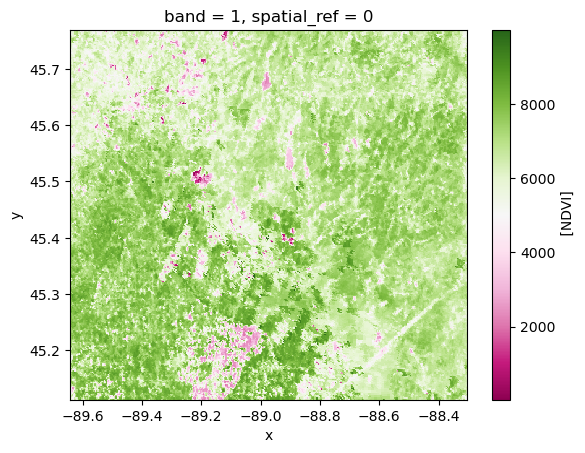

In [8]:
# Open the GeoTIFF
tif_path = ("/workspaces/data/menominee-vegetation/menominee/"
            "MOD13Q1.061_2002137_to_2025244/"
            "MOD13Q1.061__250m_16_days_NDVI_doy2008145000000_aid0001.tif")

raster = rxr.open_rasterio(tif_path)

# Plot
raster.plot(cmap="PiYG")

plt.show()

In [9]:
# Get list of NDVI tif file paths
ndvi_paths = sorted(glob(os.path.join(
    '/workspaces/data/menominee-vegetation/menominee', '**', '*NDVI*.tif')))
f'{len(ndvi_paths)} NDVI paths found'

'168 NDVI paths found'

In [10]:
from pathlib import Path

doy_start = -25
doy_end = -19

# Loop through each NDVI image
ndvi_das_dl = []
for ndvi_path in ndvi_paths:
    ndvi_path = Path(ndvi_path)

    # Get date from file name
    doy = ndvi_path.name[doy_start:doy_end]
    date = pd.to_datetime(doy, format='%Y%j')

    # Open dataset
    da = rxr.open_rasterio(ndvi_path, mask_and_scale=True).squeeze()

    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Prepare for concatenation
    ndvi_das_dl.append(da)

len(ndvi_das_dl)

168

In [11]:
# Combine NDVI images from all dates
ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])
ndvi_da

/tmp/ipykernel_1319/1684111952.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])
/tmp/ipykernel_1319/1684111952.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])


<xarray.Dataset> Size: 136MB
Dimensions:      (date: 168, y: 315, x: 642)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 5kB -89.64 -89.64 -89.64 ... -88.31 -88.31 -88.31
  * y            (y) float64 3kB 45.77 45.77 45.76 45.76 ... 45.12 45.12 45.11
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 1kB 2002-01-14 2002-01-16 ... 2025-01-24
Data variables:
    NDVI         (date, y, x) float32 136MB 0.7934 0.7651 ... 0.8006 0.7808

In [24]:
# Calculate difference in NDVI (2002 - 2013 vs. 2014 - 2025)
ndvi_diff = (
    ndvi_da
        .sel(date=slice('2007', '2012'))
        .mean('date')
        .NDVI 
   - ndvi_da
        .sel(date=slice('2002', '2007'))
        .mean('date')
        .NDVI
)
print(ndvi_diff.head())

ndvi_diff_plot = (
    ndvi_diff.hvplot(x='x', y='y', cmap='PiYG', geo=True, title='Chequamegon-Nicolet National Forest\nLakewood-Laona District\nNDVI difference: 2007-2012 minus 2002-2007')
    *
    menominee_forest_boundary.hvplot(geo=True, fill_color=None, line_color='black')
)

ndvi_diff_plot

<xarray.DataArray 'NDVI' (y: 5, x: 5)> Size: 100B
array([[ 0.00382853,  0.00151914,  0.00151914,  0.00577646,  0.01409525],
       [ 0.0065217 ,  0.0065217 ,  0.00429291,  0.00780952, -0.00923574],
       [-0.00492138, -0.00492138, -0.00813556,  0.01210719,  0.01210719],
       [-0.01500231, -0.01417845, -0.00506914,  0.00763339,  0.00763339],
       [-0.0059644 , -0.00619268,  0.00011438,  0.00011438, -0.00040704]],
      dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 40B -89.64 -89.64 -89.64 -89.63 -89.63
  * y            (y) float64 40B 45.77 45.77 45.76 45.76 45.76
    spatial_ref  int64 8B 0


:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

In [20]:
# Create interactive map with layers
wisco_layer = wisco_boundary.hvplot(geo=True,
                                    tiles='EsriImagery',
                                    color='None',
                                    edge_color='black')
ndvi_image = ndvi_diff.hvplot(
    x="x",
    y="y",
    cmap="PiYG",
    geo=True,
    alpha=0.1,   # opacity here
    title="Menominee Forest - NDVI difference: 2014-2025 minus 2002-2013"
)

boundary_layer = menominee_forest_boundary.hvplot(
    geo=True,
    fill_color=None,
    line_color="black"
)

ndvi_diff_plot = wisco_layer * ndvi_image * boundary_layer

ndvi_diff_plot

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Image.I     :Image   [x,y]   (NDVI)
   .Polygons.II :Polygons   [Longitude,Latitude]

In [21]:
# Put it all together in an interactive map

wisco_layer = wisco_boundary.hvplot(
    geo=True,
    tiles='EsriImagery',
    color='None',
    line_color='black',
    line_width=1,
    fill_alpha=1,
    width=1000,
    height=500)

ndvi_layer = ndvi_diff_plot





final_map = wisco_layer * ndvi_layer

final_map.opts(title="Menominee Vegetation Trends - 2002-2025")

:Overlay
   .WMTS.I       :WMTS   [Longitude,Latitude]
   .Polygons.I   :Polygons   [Longitude,Latitude]
   .WMTS.II      :WMTS   [Longitude,Latitude]
   .Polygons.II  :Polygons   [Longitude,Latitude]
   .Image.I      :Image   [x,y]   (NDVI)
   .Polygons.III :Polygons   [Longitude,Latitude]

In [12]:
wisco_boundary.hvplot(
    geo=True,
    tiles='CartoLight',
    color='None',
    line_color='black',
    line_width=1,
    fill_alpha=1,
    width=1000,
    height=500)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [13]:
# Extract the polygon
polygon = menominee_forest_boundary.geometry.iloc[0]

# Download power infrastructure
roads = osm.features_from_polygon(
    polygon,
    tags={
        "highway":True
    }
)

roads.head()

geometry         highway direction  \
element id                                                                
node    231024840  POINT (-88.55804 45.66102)  turning_circle       NaN   
        231025929  POINT (-88.63439 45.59361)  turning_circle       NaN   
        231031136  POINT (-88.78098 45.46448)  turning_circle       NaN   
        231043276  POINT (-88.68549 45.58046)  turning_circle       NaN   
        231045918  POINT (-88.68505 45.50234)  turning_circle       NaN   

                  crossing crossing:markings name name_1 tiger:cfcc  \
element id                                                            
node    231024840      NaN               NaN  NaN    NaN        NaN   
        231025929      NaN               NaN  NaN    NaN        NaN   
        231031136      NaN               NaN  NaN    NaN        NaN   
        231043276      NaN               NaN  NaN    NaN        NaN   
        231045918      NaN               NaN  NaN    NaN        NaN   

                  tiger:county tiger:name_base  ... name_3 tiger:name_base_3  \
element id                                      ...                            
node    231024840          NaN             NaN  ...    NaN               NaN   
        231025929          NaN             NaN  ...    NaN               NaN   
        231031136          NaN             NaN  ...    NaN               NaN   
        231043276          NaN             NaN  ...    NaN               NaN   
        231045918          NaN             NaN  ...    NaN               NaN   

                  tiger:name_type_3 designation area footway leisure informal  \
element id                                                                      
node    231024840               NaN         NaN  NaN     NaN     NaN      NaN   
        231025929               NaN         NaN  NaN     NaN     NaN      NaN   
        231031136               NaN         NaN  NaN     NaN     NaN      NaN   
        231043276               NaN         NaN  NaN     NaN     NaN      NaN   
        231045918               NaN         NaN  NaN     NaN     NaN      NaN   

                  maxheight incline  
element id                           
node    231024840       NaN     NaN  
        231025929       NaN     NaN  
        231031136       NaN     NaN  
        231043276       NaN     NaN  
        231045918       NaN     NaN  

[5 rows x 89 columns]

<Axes: >

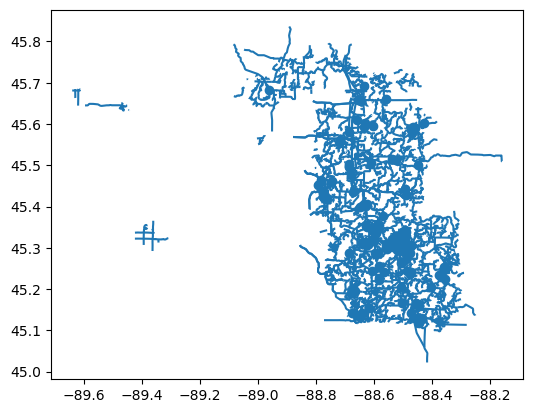

In [15]:
roads.plot()

In [17]:
# Separate road lines

menominee_road_lines = roads[
    roads.geometry.geom_type.isin(["LineString", "MultiLineString"])
].copy()

menominee_road_lines

geometry  \
element id                                                              
way     21474427    LINESTRING (-88.67588 45.73686, -88.67534 45.7...   
        21474656    LINESTRING (-88.58075 45.61816, -88.58106 45.6...   
        21474674    LINESTRING (-88.58126 45.6192, -88.58143 45.61...   
        21474678    LINESTRING (-88.65419 45.60767, -88.65505 45.6...   
        21474680    LINESTRING (-88.56652 45.60592, -88.56669 45.6...   
...                                                               ...   
        1529897807  LINESTRING (-88.5028 45.51575, -88.50279 45.51...   
        1529897812  LINESTRING (-88.5285 45.5141, -88.52852 45.514...   
        1529897813  LINESTRING (-88.52898 45.51334, -88.52908 45.5...   
        1529897814  LINESTRING (-88.52902 45.5134, -88.52908 45.51...   
        1529897815  LINESTRING (-88.5302 45.51183, -88.53004 45.51...   

                         highway direction crossing crossing:markings  \
element id                                                              
way     21474427    unclassified       NaN      NaN               NaN   
        21474656    unclassified       NaN      NaN               NaN   
        21474674    unclassified       NaN      NaN               NaN   
        21474678    unclassified       NaN      NaN               NaN   
        21474680    unclassified       NaN      NaN               NaN   
...                          ...       ...      ...               ...   
        1529897807          path       NaN      NaN               NaN   
        1529897812       footway       NaN      NaN               NaN   
        1529897813       footway       NaN      NaN               NaN   
        1529897814       footway       NaN      NaN               NaN   
        1529897815         steps       NaN      NaN               NaN   

                                       name            name_1 tiger:cfcc  \
element id                                                                 
way     21474427               Jauquet Road       Newald Road        A41   
        21474656        Peshtigo River Road               NaN        NaN   
        21474674                Browns Road  Forest Road 2132        A41   
        21474678                Browns Road               NaN        NaN   
        21474680        Peshtigo River Road               NaN        NaN   
...                                     ...               ...        ...   
        1529897807  Halley Creek Bird Trail               NaN        NaN   
        1529897812                      NaN               NaN        NaN   
        1529897813                      NaN               NaN        NaN   
        1529897814                      NaN               NaN        NaN   
        1529897815                      NaN               NaN        NaN   

                    tiger:county tiger:name_base  ... name_3  \
element id                                        ...          
way     21474427    Florence, WI         Jauquet  ...    NaN   
        21474656             NaN             NaN  ...    NaN   
        21474674      Forest, WI          Browns  ...    NaN   
        21474678             NaN             NaN  ...    NaN   
        21474680             NaN             NaN  ...    NaN   
...                          ...             ...  ...    ...   
        1529897807           NaN             NaN  ...    NaN   
        1529897812           NaN             NaN  ...    NaN   
        1529897813           NaN             NaN  ...    NaN   
        1529897814           NaN             NaN  ...    NaN   
        1529897815           NaN             NaN  ...    NaN   

                   tiger:name_base_3 tiger:name_type_3 designation area  \
element id                                                                
way     21474427                 NaN               NaN         NaN  NaN   
        21474656                 NaN               NaN         NaN  NaN   
        21474674                 NaN   

<Axes: >

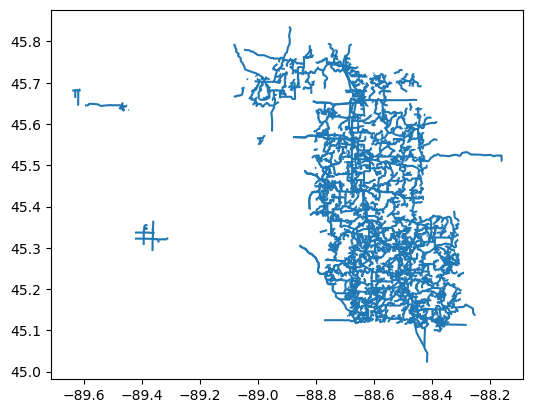

In [21]:
menominee_road_lines.plot()

In [22]:
# Put it all together in an interactive map

wisco_layer = wisco_boundary.hvplot(
    geo=True,
    tiles='CartoLight',
    color='None',
    line_color='black',
    line_width=1,
    fill_alpha=1,
    width=1000,
    height=500)

menominee_road_lines_layer = menominee_road_lines.hvplot()

ndvi_layer = ndvi_diff_plot







final_map = menominee_road_lines_layer * wisco_layer * ndvi_layer

final_map.opts(title="Menominee Vegetation Trends - 2002-2025")

:Overlay
   .Path.I      :Path   [x,y]
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Image.I     :Image   [x,y]   (NDVI)
   .Polygons.II :Polygons   [Longitude,Latitude]